# Segmentasi Profil Fisik & Pola Hidup - Nashrullah Hidayat Akbar 51423073

## 1. Business Understanding

### Latar Belakang

Setiap individu memiliki karakteristik fisik dan pola hidup yang berbeda, seperti usia,
tinggi badan, berat badan, pola makan, konsumsi air, serta aktivitas fisik.
Perbedaan karakteristik tersebut dapat digunakan untuk menemukan kelompok individu
yang memiliki pola atau karakteristik yang serupa.

Pada Tugas ini, metode clustering digunakan untuk melakukan segmentasi individu
berdasarkan karakteristik fisik dan pola hidup tanpa menggunakan label sebagai dasar
pembentukan cluster.

### Permasalahan

Bagaimana mengelompokkan individu berdasarkan kemiripan karakteristik fisik dan
pola hidup menggunakan algoritma K-Means Clustering?


### Tujuan

1. Mengidentifikasi kelompok individu berdasarkan karakteristik fisik dan pola hidup.
2. Menentukan jumlah cluster yang sesuai berdasarkan hasil evaluasi.
3. Menganalisis karakteristik dari setiap cluster yang terbentuk.

## 2. Data Understanding

Dataset yang digunakan adalah **Estimation of Obesity Levels Based On Eating Habits
and Physical Condition** yang diperoleh dari UCI Machine Learning Repository.

Dataset digunakan untuk menganalisis karakteristik fisik, kebiasaan makan,
aktivitas fisik, dan pola hidup individu sebagai dasar pembentukan cluster.

In [1]:
#1. Import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#2. Baca dataset

df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
#3. Ketahui Jumlah kolom baris dataset

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 2111
Jumlah kolom : 17


In [4]:
#4. cek struktur kolom

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [5]:
#5. cari tau missing value

df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [6]:
#6. Cek data duplikat

jumlah_duplikat = df.duplicated().sum()

print("Jumlah data duplikat:", jumlah_duplikat)

Jumlah data duplikat: 24


### Pemeriksaan Data Duplikat

Hasil pemeriksaan menunjukkan terdapat **24 baris data duplikat** dari total 2.111 baris dataset.

Data duplikat perlu diperhatikan karena baris yang identik dapat memberikan bobot tambahan terhadap karakteristik tertentu dalam proses clustering. Oleh karena itu, pada tahap **Data Preparation**, data duplikat akan dihapus sebelum proses pemodelan.

In [7]:
#7. Statistik deskriptif fitur numerik

df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


### Statistik Deskriptif

Berdasarkan statistik deskriptif, dataset memiliki variasi pada karakteristik fisik dan pola hidup individu. Variabel `Age`, `Height`, dan `Weight` menggambarkan karakteristik fisik, sedangkan `FCVC`, `NCP`, `CH2O`, `FAF`, dan `TUE` menggambarkan beberapa aspek pola makan, konsumsi air, aktivitas fisik, dan penggunaan teknologi.

Variabel numerik memiliki rentang dan skala yang berbeda. Perbedaan skala tersebut akan menjadi pertimbangan pada tahap Data Preparation karena algoritma K-Means menggunakan perhitungan jarak dalam menentukan kedekatan antar data.

In [8]:
# Melihat statistik variabel kategorikal

df.describe(include='object').T

,count,unique,top,freq
Gender,2111,2,Male,1068
family_history_with_overweight,2111,2,yes,1726
FAVC,2111,2,yes,1866
CAEC,2111,4,Sometimes,1765
SMOKE,2111,2,no,2067
SCC,2111,2,no,2015
CALC,2111,4,Sometimes,1401
MTRANS,2111,5,Public_Transportation,1580
NObeyesdad,2111,7,Obesity_Type_I,351


### Analisis Variabel Kategorikal

Dataset memiliki 9 variabel kategorikal dengan jumlah kategori yang berbeda-beda. 
Variabel tersebut mencakup jenis kelamin, riwayat keluarga dengan kelebihan berat badan,
kebiasaan konsumsi makanan tertentu, kebiasaan merokok, konsumsi alkohol,
transportasi yang digunakan, serta kategori tingkat obesitas.

Variabel `NObeyesdad` memiliki 7 kategori dan akan digunakan sebagai informasi tambahan
untuk membantu interpretasi hasil clustering. Variabel tersebut tidak digunakan sebagai
fitur dalam proses pembentukan cluster karena clustering dilakukan tanpa menggunakan
label atau target.

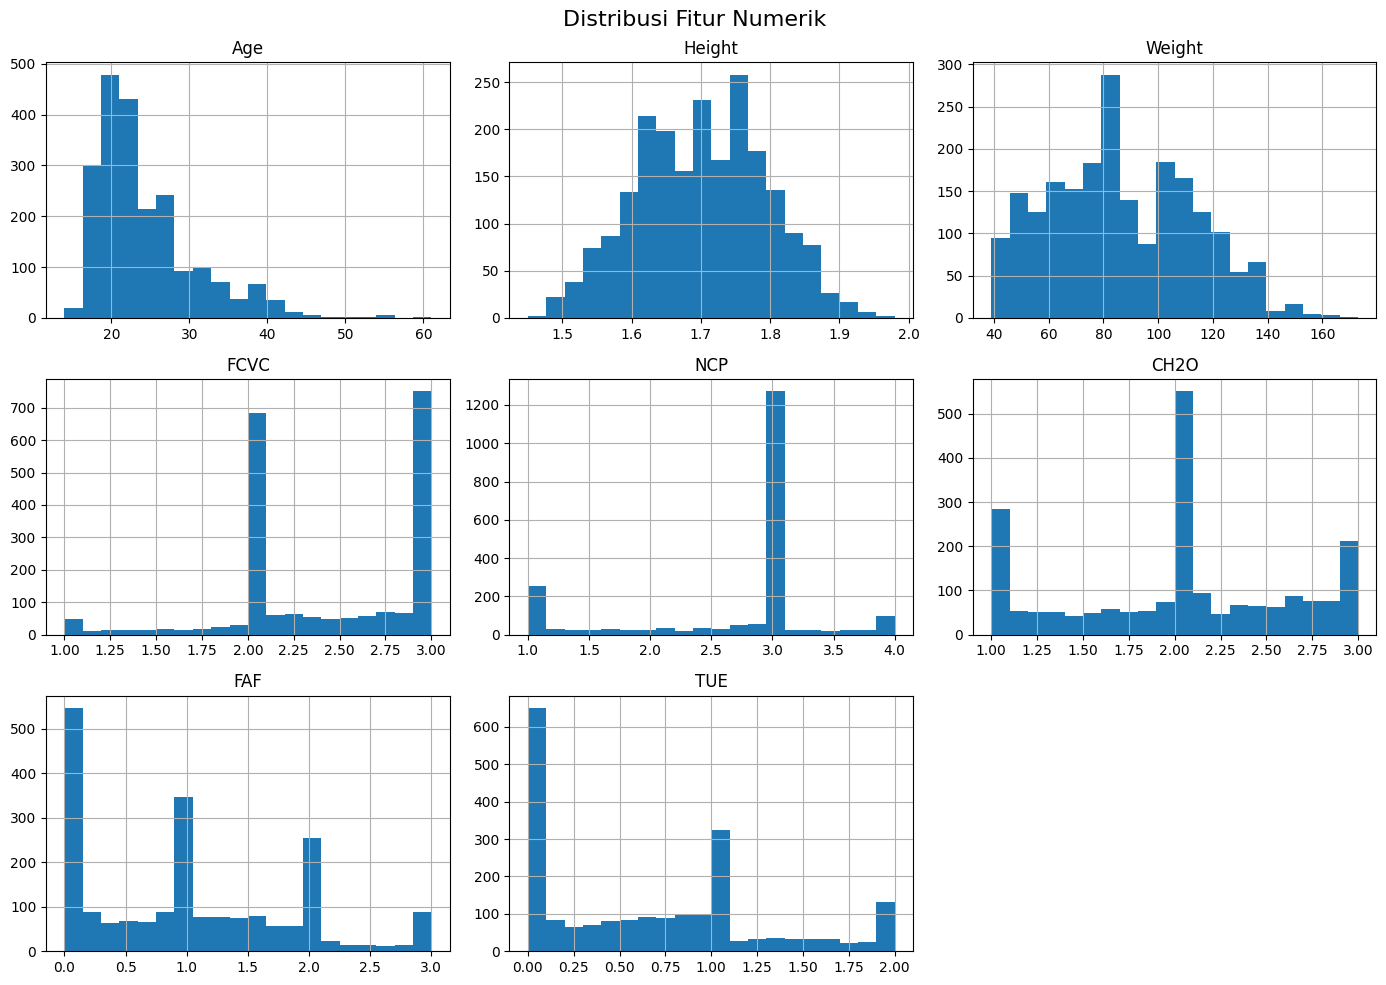

In [9]:
#8. Visualisasi distribusi fitur numerik

numeric_features = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE"
]

df[numeric_features].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Distribusi Fitur Numerik", fontsize=16)
plt.tight_layout()
plt.show()

### Analisis Distribusi Fitur Numerik

Berdasarkan visualisasi distribusi, setiap fitur numerik memiliki karakteristik
distribusi yang berbeda. Variabel `Age` dan `Weight` memiliki distribusi yang
cenderung miring ke kanan, sedangkan `Height` memiliki distribusi yang relatif
lebih menyebar di sekitar nilai tengah.

Variabel `FCVC`, `NCP`, `CH2O`, `FAF`, dan `TUE` memiliki rentang nilai yang
terbatas karena merepresentasikan frekuensi atau skala kebiasaan tertentu.
Distribusi tersebut menunjukkan bahwa karakteristik setiap fitur tidak sama,
sehingga perlu dilakukan preprocessing sebelum digunakan dalam algoritma
K-Means.

Perbedaan skala antarfitur akan ditangani dengan proses standardisasi pada
tahap Data Preparation.

In [10]:
#9. Mengecek nilai minimum dan maksimum fitur numerik

for col in numeric_features:
    print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")

Age: min = 14.0, max = 61.0
Height: min = 1.45, max = 1.98
Weight: min = 39.0, max = 173.0
FCVC: min = 1.0, max = 3.0
NCP: min = 1.0, max = 4.0
CH2O: min = 1.0, max = 3.0
FAF: min = 0.0, max = 3.0
TUE: min = 0.0, max = 2.0


### Pemeriksaan Rentang Nilai

Hasil pemeriksaan nilai minimum dan maksimum menunjukkan bahwa seluruh fitur numerik
berada dalam rentang nilai yang sesuai dengan karakteristik masing-masing variabel.

- `Age` berada pada rentang 14–61 tahun.
- `Height` berada pada rentang 1,45–1,98 meter.
- `Weight` berada pada rentang 39–173 kg.
- `FCVC` berada pada rentang 1–3.
- `NCP` berada pada rentang 1–4.
- `CH2O` berada pada rentang 1–3.
- `FAF` berada pada rentang 0–3.
- `TUE` berada pada rentang 0–2.

Tidak ditemukan nilai yang berada di luar rentang yang ditentukan oleh dataset,
sehingga tidak dilakukan penghapusan data berdasarkan batas nilai tersebut.

## 3. Data Preparation

### Menghapus Data Duplikat

Berdasarkan hasil pemeriksaan pada tahap Data Understanding, ditemukan 24 baris
data duplikat. Data tersebut dihapus agar setiap observasi hanya dihitung satu kali
dalam proses clustering.

In [11]:
#1. Menghapus data duplikat

df = df.drop_duplicates().reset_index(drop=True)
print("Jumlah baris setelah menghapus duplikasi:", df.shape[0])

Jumlah baris setelah menghapus duplikasi: 2087


### Pemilihan Fitur

Pada tugas ini, fitur yang digunakan untuk proses clustering adalah fitur
numerik yang merepresentasikan karakteristik fisik dan pola hidup individu, yaitu
`Age`, `Height`, `Weight`, `FCVC`, `NCP`, `CH2O`, `FAF`, dan `TUE`.

Kolom `NObeyesdad` tidak digunakan sebagai fitur pembentukan cluster karena
merupakan label kategori tingkat obesitas. Label tersebut akan digunakan sebagai
informasi tambahan pada tahap interpretasi hasil clustering.

Fitur kategorikal lainnya tidak digunakan dalam pemodelan K-Means pada tugas
ini karena fokus awal clustering menggunakan fitur numerik yang dapat diproses
berdasarkan perhitungan jarak.

In [13]:
#2. Memilih fitur yang digunakan untuk clustering

cluster_features = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE"
]

X = df[cluster_features].copy()

print("Jumlah data:", X.shape[0])
print("Jumlah fitur:", X.shape[1])

display(X.head())

Jumlah data: 2087
Jumlah fitur: 8


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0


### Standardisasi Data

Fitur yang digunakan memiliki skala nilai yang berbeda. Sebagai contoh, `Weight`
memiliki rentang nilai yang jauh lebih besar dibandingkan `FAF` dan `TUE`.

Karena algoritma K-Means menggunakan jarak antar data dalam proses pembentukan
cluster, perbedaan skala dapat menyebabkan fitur dengan nilai numerik lebih besar
memberikan pengaruh yang lebih besar terhadap hasil clustering.

Oleh karena itu, dilakukan standardisasi menggunakan `StandardScaler` agar setiap
fitur memiliki skala yang sebanding.

In [16]:
from sklearn.preprocessing import StandardScaler

#3. Membuat objek StandardScaler & Melakukan standardisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#4. Mengubah hasil standardisasi menjadi DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=cluster_features
)

print("Data sebelum standardisasi:")
display(X.head())

print("\nData setelah standardisasi:")
display(X_scaled.head())

Data sebelum standardisasi:


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0



Data setelah standardisasi:


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,-0.526613,-0.887408,-0.872985,-0.788364,0.390906,-0.007810,-1.186977,0.554211
1,-0.526613,-1.960788,-1.178508,1.082164,0.390906,1.636552,2.328908,-1.090505
2,-0.212507,1.044677,-0.376509,-0.788364,0.390906,-0.007810,1.156947,0.554211
3,0.415705,1.044677,0.005395,1.082164,0.390906,-0.007810,1.156947,-1.090505
4,-0.369560,0.830001,0.112328,-0.788364,-2.225418,-0.007810,-1.186977,-1.090505


## 4. Modeling

### Menentukan Jumlah Cluster

Sebelum menerapkan algoritma K-Means, perlu ditentukan jumlah cluster yang sesuai.
Pada penelitian ini digunakan **Elbow Method** untuk mengamati perubahan nilai inertia
pada beberapa jumlah cluster.

Jumlah cluster yang diuji adalah 2 sampai 10 cluster.

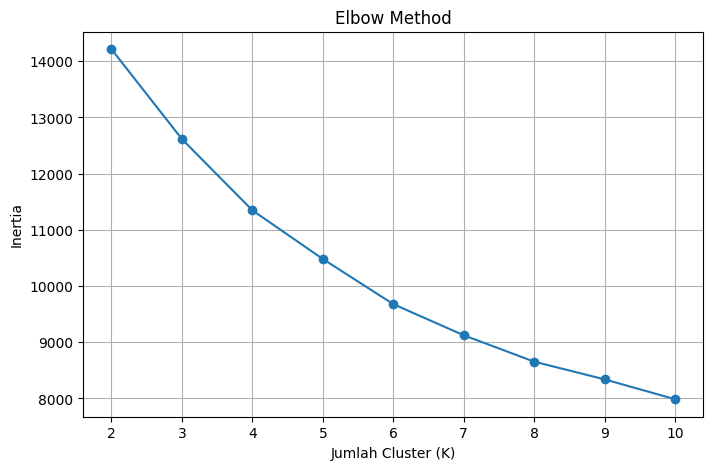

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#5. Menyimpan nilai inertia & Menguji jumlah cluster dari 2 sampai 10
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(K)
plt.grid(True)
plt.show()

### Evaluasi Jumlah Cluster dengan Silhouette Score

Elbow Method menunjukkan bahwa penurunan inertia mulai melandai pada jumlah cluster
sekitar 4 hingga 5. Karena titik elbow tidak terlihat sangat tegas, dilakukan evaluasi
tambahan menggunakan **Silhouette Score**. guna untuk mengukur seberapa baik setiap data berada di dalam
cluster-nya dibandingkan dengan cluster lainnya. Nilai yang lebih tinggi menunjukkan
pemisahan cluster yang lebih baik.

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

#6. Menguji K dari 2 sampai 15
for k in range(2, 16):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Menampilkan hasil
for k, score in zip(range(2, 16), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.1450
K = 3: Silhouette Score = 0.1499
K = 4: Silhouette Score = 0.1585
K = 5: Silhouette Score = 0.1598
K = 6: Silhouette Score = 0.1647
K = 7: Silhouette Score = 0.1647
K = 8: Silhouette Score = 0.1666
K = 9: Silhouette Score = 0.1774
K = 10: Silhouette Score = 0.1776
K = 11: Silhouette Score = 0.1770
K = 12: Silhouette Score = 0.1854
K = 13: Silhouette Score = 0.1868
K = 14: Silhouette Score = 0.1894
K = 15: Silhouette Score = 0.1892


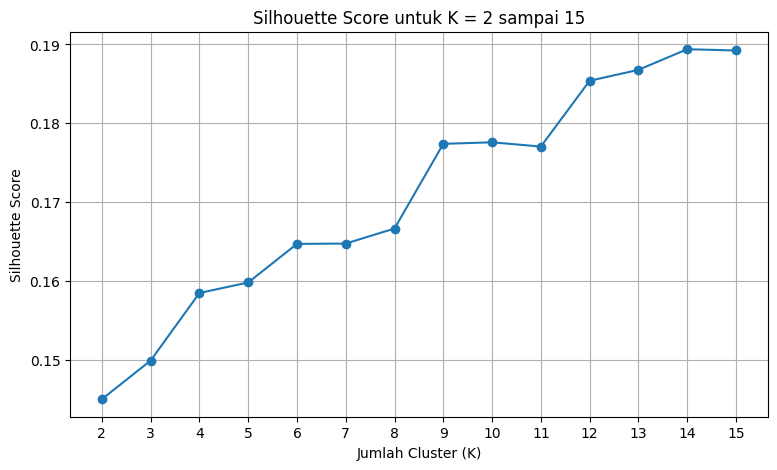

In [21]:
plt.figure(figsize=(9, 5))
plt.plot(range(2, 16), silhouette_scores, marker='o')
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score untuk K = 2 sampai 15")
plt.xticks(range(2, 16))
plt.grid(True)
plt.show()

### Hasil Evaluasi Jumlah Cluster

Berdasarkan pengujian menggunakan Silhouette Score pada K = 2 sampai K = 15,
nilai Silhouette Score cenderung meningkat seiring bertambahnya jumlah cluster.

Nilai tertinggi diperoleh pada K = 14 dengan Silhouette Score sebesar **0,1894**,
sedangkan pada K = 15 nilainya sedikit menurun menjadi **0,1892**.

Dengan demikian, K = 14 menjadi kandidat jumlah cluster yang akan digunakan.
Namun, sebelum menetapkan jumlah cluster secara final, perlu dilakukan pemeriksaan
terhadap jumlah anggota pada setiap cluster untuk memastikan tidak terdapat cluster
dengan ukuran yang terlalu kecil.

In [22]:
#7. Membuat model K-Means dengan K = 14

kmeans_14 = KMeans(
    n_clusters=14,
    random_state=42,
    n_init=10
)

labels_14 = kmeans_14.fit_predict(X_scaled)

# Menghitung jumlah anggota setiap cluster
cluster_counts = pd.Series(labels_14).value_counts().sort_index()

print("Jumlah anggota setiap cluster:")
print(cluster_counts)

Jumlah anggota setiap cluster:
0     196
1     189
2     180
3     124
4      98
5     142
6     133
7     133
8     145
9     126
10    125
11    148
12    170
13    178
Name: count, dtype: int64


### Pembentukan Model K-Means Final

Berdasarkan hasil evaluasi jumlah cluster menggunakan Elbow Method dan Silhouette
Score, serta pemeriksaan distribusi jumlah anggota cluster, digunakan **14 cluster**
sebagai konfigurasi model K-Means final.

Pada K = 14 diperoleh Silhouette Score sebesar **0,1894**. Seluruh cluster juga
memiliki jumlah anggota yang mencukupi, dengan jumlah anggota terkecil sebanyak
98 data dan terbesar sebanyak 196 data.

In [23]:
#8. Membentuk model K-Means final dengan 14 cluster

kmeans_final = KMeans(
    n_clusters=14,
    random_state=42,
    n_init=10
)

# Menentukan cluster untuk setiap data
df["Cluster"] = kmeans_final.fit_predict(X_scaled)

print("Model K-Means final berhasil dibuat.")
print("Jumlah data:", len(df))
print("Jumlah cluster:", df["Cluster"].nunique())

Model K-Means final berhasil dibuat.
Jumlah data: 2087
Jumlah cluster: 14


In [24]:
# Melihat jumlah data pada setiap cluster

cluster_counts = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

display(cluster_counts.to_frame("Jumlah Data"))

,Jumlah Data
Cluster,
0,196
1,189
2,180
3,124
4,98
5,142
6,133
7,133
8,145


### Analisis Karakteristik Cluster

Setelah model K-Means terbentuk, dilakukan analisis terhadap karakteristik setiap
cluster berdasarkan nilai rata-rata fitur yang digunakan dalam proses clustering.

Analisis ini bertujuan untuk mengetahui perbedaan karakteristik fisik dan pola hidup
pada masing-masing kelompok yang terbentuk.

In [25]:
#9. Menghitung rata-rata setiap fitur pada masing-masing cluster

cluster_profile = df.groupby("Cluster")[cluster_features].mean()

display(cluster_profile.round(2))

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
Cluster,,,,,,,,
0,19.95,1.74,64.40,2.87,3.22,2.19,1.93,0.57
1,22.42,1.77,131.48,2.96,2.98,2.31,1.39,0.85
2,22.82,1.64,82.13,2.94,3.01,1.38,0.55,0.63
3,19.88,1.66,62.15,1.67,3.12,1.37,0.77,1.13
4,40.50,1.61,74.65,2.36,2.89,1.76,0.39,0.17
5,25.76,1.64,106.62,2.99,3.00,2.62,0.09,0.36
6,22.46,1.60,62.86,2.37,1.16,1.83,0.49,0.18
7,20.82,1.72,71.47,2.05,3.06,2.31,2.33,1.49
8,22.22,1.65,68.65,2.03,3.05,1.93,0.93,0.12


### Visualisasi Profil Cluster

Untuk mempermudah perbandingan karakteristik antarcluster, dilakukan visualisasi
rata-rata setiap fitur pada masing-masing cluster menggunakan heatmap.
Visualisasi ini digunakan untuk melihat pola fitur yang relatif lebih tinggi atau
lebih rendah pada setiap cluster.

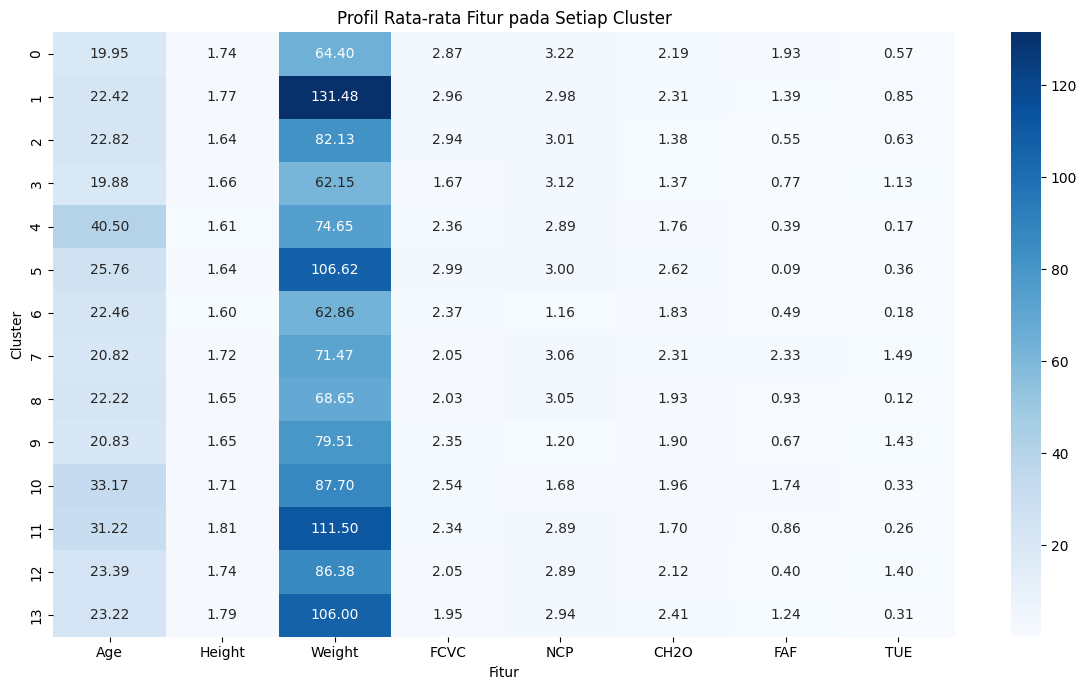

In [27]:
#10. Heatmap profil rata-rata setiap cluster

plt.figure(figsize=(12, 7))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Profil Rata-rata Fitur pada Setiap Cluster")
plt.xlabel("Fitur")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

### Visualisasi Profil Relatif Antarcluster

Karena setiap fitur memiliki skala yang berbeda, heatmap berdasarkan nilai rata-rata
asli dapat didominasi oleh fitur dengan rentang angka yang lebih besar seperti
`Weight`.

Oleh karena itu, dilakukan standardisasi terhadap profil rata-rata setiap cluster
untuk membandingkan posisi relatif masing-masing fitur terhadap cluster lainnya.

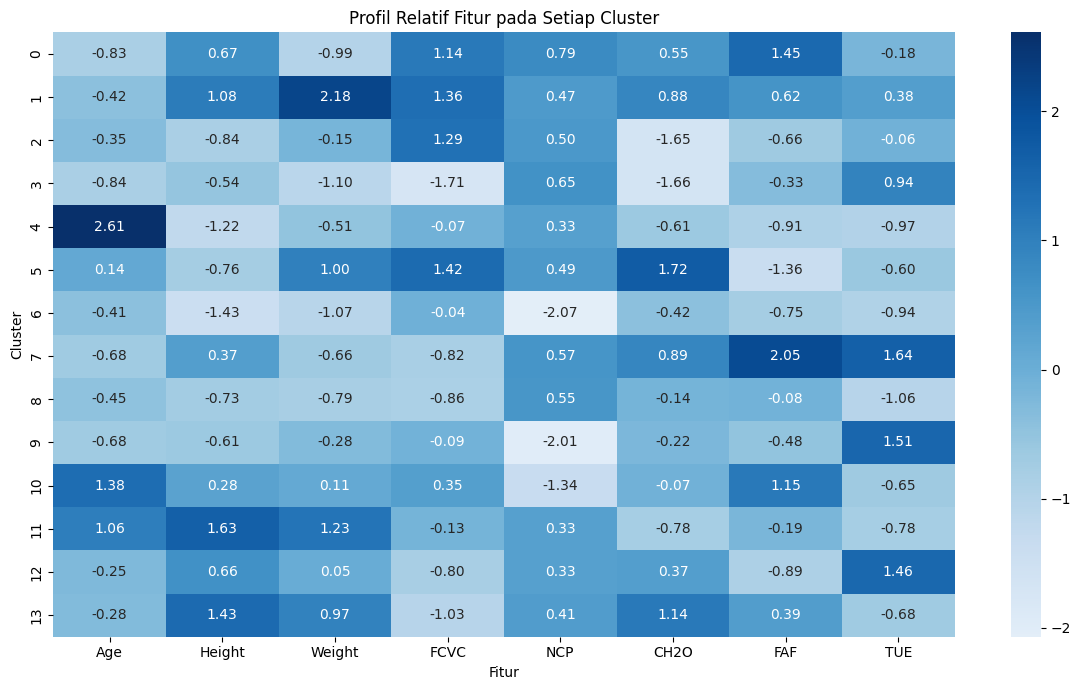

In [28]:
#11. Standardisasi profil rata-rata antarcluster

cluster_profile_scaled = (
    cluster_profile - cluster_profile.mean()
) / cluster_profile.std()

plt.figure(figsize=(12, 7))

sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    center=0
)

plt.title("Profil Relatif Fitur pada Setiap Cluster")
plt.xlabel("Fitur")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

### Profil dan Ukuran Cluster

Profil setiap cluster dianalisis berdasarkan nilai rata-rata fitur numerik dan jumlah
anggota pada masing-masing cluster. Nilai rata-rata digunakan untuk mengidentifikasi
karakteristik yang membedakan setiap kelompok.

In [29]:
#12. Membuat tabel profil cluster beserta jumlah anggota

cluster_summary = cluster_profile.copy()

cluster_summary["Jumlah Data"] = df["Cluster"].value_counts().sort_index()

display(cluster_summary.round(2))

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Jumlah Data
Cluster,,,,,,,,,
0,19.95,1.74,64.40,2.87,3.22,2.19,1.93,0.57,196
1,22.42,1.77,131.48,2.96,2.98,2.31,1.39,0.85,189
2,22.82,1.64,82.13,2.94,3.01,1.38,0.55,0.63,180
3,19.88,1.66,62.15,1.67,3.12,1.37,0.77,1.13,124
4,40.50,1.61,74.65,2.36,2.89,1.76,0.39,0.17,98
5,25.76,1.64,106.62,2.99,3.00,2.62,0.09,0.36,142
6,22.46,1.60,62.86,2.37,1.16,1.83,0.49,0.18,133
7,20.82,1.72,71.47,2.05,3.06,2.31,2.33,1.49,133
8,22.22,1.65,68.65,2.03,3.05,1.93,0.93,0.12,145


In [31]:
#13. Evaluasi model K-Means final

final_silhouette = silhouette_score(X_scaled, df["Cluster"])

print(f"Silhouette Score Model K-Means Final: {final_silhouette:.4f}")

Silhouette Score Model K-Means Final: 0.1894


### Visualisasi Cluster dengan PCA

Untuk memvisualisasikan hasil clustering yang memiliki 8 fitur numerik, saya make
Principal Component Analysis (PCA) untuk mereduksi dimensi data menjadi dua komponen
utama, yaitu PC1 dan PC2.

PCA digunakan cuma untuk keperluan visualisasi dan tidak mengubah hasil cluster yang
telah diperoleh dari model K-Means.

In [32]:
from sklearn.decomposition import PCA

#14. Mengurangi dimensi data dari 8 fitur menjadi 2 komponen
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Membuat DataFrame hasil PCA
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Menambahkan label cluster
pca_df["Cluster"] = df["Cluster"].values

print("Variance yang dijelaskan oleh PC1:", round(pca.explained_variance_ratio_[0], 4))
print("Variance yang dijelaskan oleh PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Total variance yang dijelaskan:",
      round(pca.explained_variance_ratio_.sum(), 4))

Variance yang dijelaskan oleh PC1: 0.2255
Variance yang dijelaskan oleh PC2: 0.1876
Total variance yang dijelaskan: 0.4131


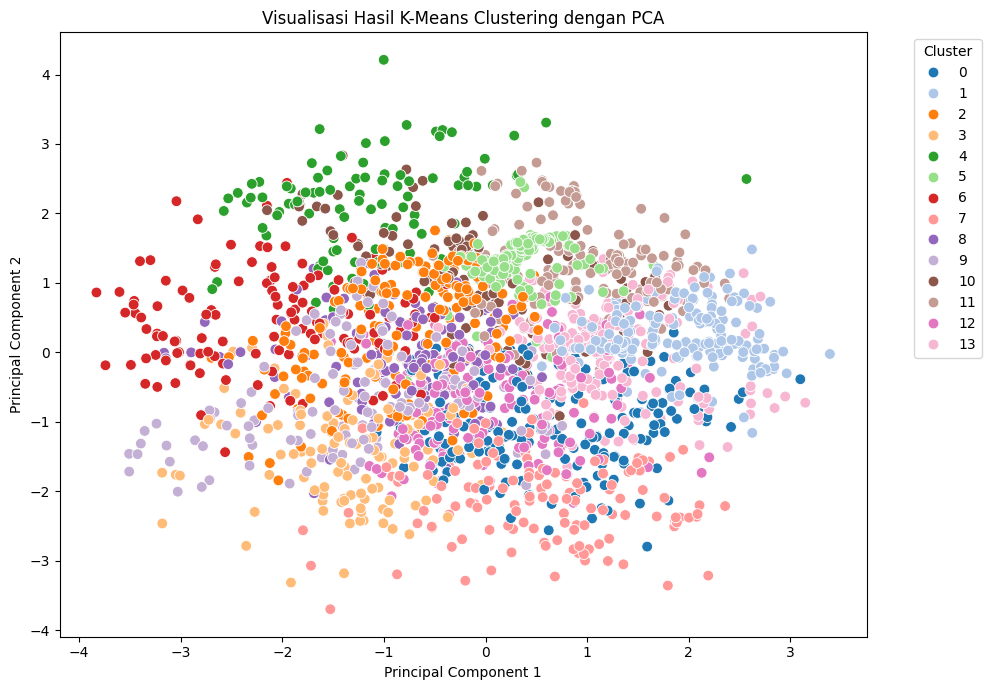

In [33]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab20",
    s=60
)

plt.title("Visualisasi Hasil K-Means Clustering dengan PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

### Analisis Distribusi Kategori pada Setiap Cluster

Untuk membantu menginterpretasikan hasil clustering, dilakukan analisis distribusi
kategori `NObeyesdad` pada setiap cluster.

Variabel `NObeyesdad` tidak digunakan dalam proses pembentukan cluster. Variabel ini
hanya digunakan setelah clustering untuk melihat apakah terdapat perbedaan komposisi
kategori tingkat obesitas pada kelompok yang terbentuk.

In [34]:
# Distribusi NObeyesdad pada setiap cluster

cluster_obesity = pd.crosstab(
    df["Cluster"],
    df["NObeyesdad"]
)

display(cluster_obesity)

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,96,48,5,0,0,21,26
1,0,0,13,42,134,0,0
2,26,25,15,14,63,18,19
3,39,45,17,0,0,13,10
4,2,9,43,0,0,21,23
5,1,4,2,0,127,0,8
6,38,22,25,1,0,26,21
7,35,32,26,0,0,18,22
8,12,43,25,0,0,48,17


In [35]:
# Persentase NObeyesdad pada setiap cluster

cluster_obesity_pct = pd.crosstab(
    df["Cluster"],
    df["NObeyesdad"],
    normalize="index"
) * 100

display(cluster_obesity_pct.round(2))

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,48.98,24.49,2.55,0.00,0.00,10.71,13.27
1,0.00,0.00,6.88,22.22,70.90,0.00,0.00
2,14.44,13.89,8.33,7.78,35.00,10.00,10.56
3,31.45,36.29,13.71,0.00,0.00,10.48,8.06
4,2.04,9.18,43.88,0.00,0.00,21.43,23.47
5,0.70,2.82,1.41,0.00,89.44,0.00,5.63
6,28.57,16.54,18.80,0.75,0.00,19.55,15.79
7,26.32,24.06,19.55,0.00,0.00,13.53,16.54
8,8.28,29.66,17.24,0.00,0.00,33.10,11.72


### Visualisasi Distribusi Kategori pada Setiap Cluster

Distribusi kategori `NObeyesdad` pada setiap cluster divisualisasikan dalam bentuk
stacked bar chart untuk mempermudah perbandingan komposisi kategori antarcluster.
Visualisasi ini digunakan sebagai analisis tambahan terhadap karakteristik cluster
yang telah terbentuk.

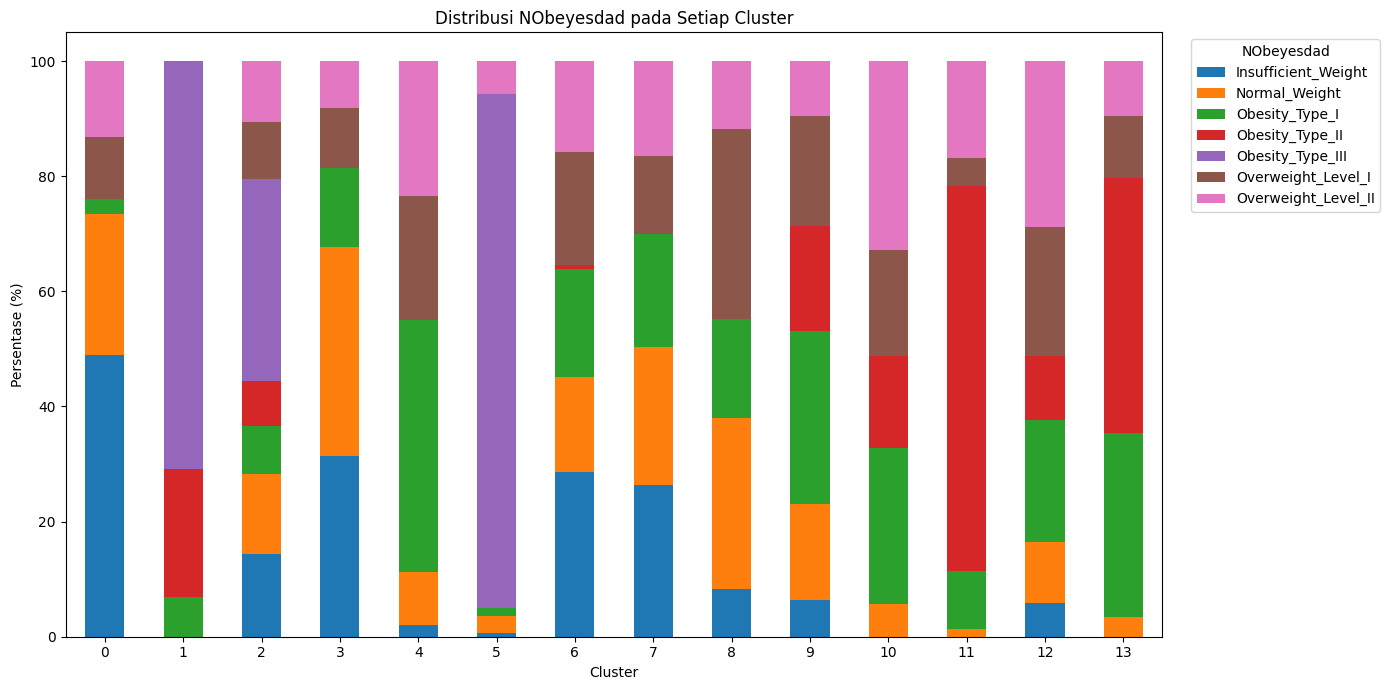

In [36]:
# Visualisasi persentase NObeyesdad pada setiap cluster

cluster_obesity_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Distribusi NObeyesdad pada Setiap Cluster")
plt.xlabel("Cluster")
plt.ylabel("Persentase (%)")
plt.legend(
    title="NObeyesdad",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Silhouette Score Setiap Cluster

Selain mengevaluasi nilai Silhouette Score secara keseluruhan, dilakukan analisis
Silhouette Score pada masing-masing cluster untuk melihat kualitas pengelompokan
secara lebih rinci.

Nilai yang lebih tinggi menunjukkan bahwa data dalam cluster tersebut relatif lebih
dekat dengan anggotanya dibandingkan dengan cluster lainnya.

In [37]:
from sklearn.metrics import silhouette_samples

# Menghitung silhouette score untuk setiap data
sample_silhouette = silhouette_samples(
    X_scaled,
    df["Cluster"]
)

# Menambahkan score ke dataframe
df["Silhouette"] = sample_silhouette

# Rata-rata silhouette setiap cluster
cluster_silhouette = (
    df.groupby("Cluster")["Silhouette"]
    .mean()
    .sort_values()
)

display(cluster_silhouette.round(4).to_frame("Silhouette Score"))

,Silhouette Score
Cluster,
10,0.0766
11,0.1072
2,0.1138
12,0.1211
9,0.1234
0,0.1335
3,0.1370
8,0.1505
7,0.1653


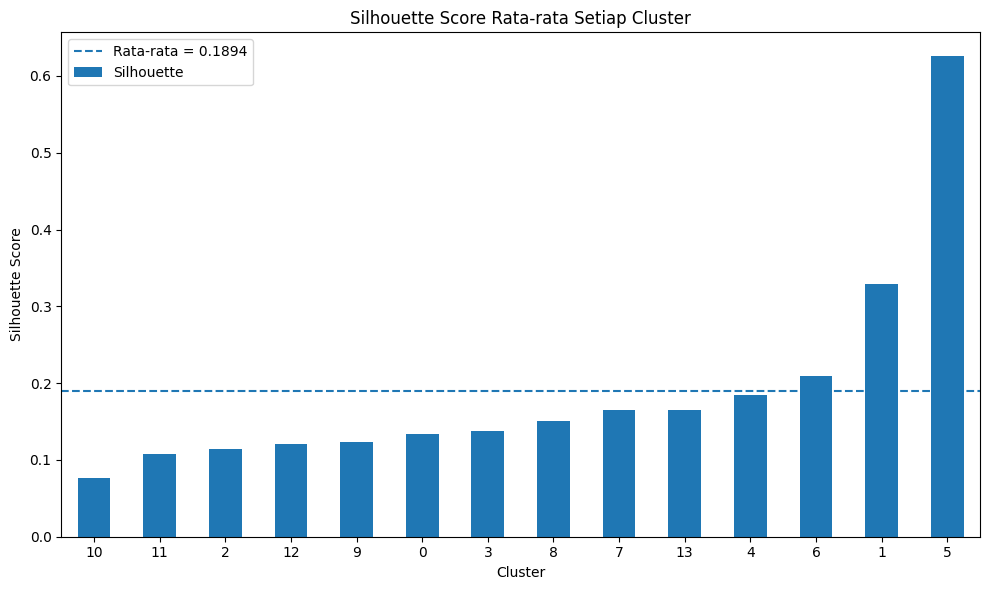

In [38]:
plt.figure(figsize=(10, 6))

cluster_silhouette.sort_values().plot(
    kind="bar"
)

plt.axhline(
    y=final_silhouette,
    linestyle="--",
    label=f"Rata-rata = {final_silhouette:.4f}"
)

plt.title("Silhouette Score Rata-rata Setiap Cluster")
plt.xlabel("Cluster")
plt.ylabel("Silhouette Score")
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Analisis Silhouette Score per Cluster

Hasil evaluasi menunjukkan bahwa kualitas pengelompokan berbeda pada setiap cluster.
Cluster 5 memiliki rata-rata Silhouette Score paling tinggi, sedangkan Cluster 10
memiliki nilai paling rendah.

Perbedaan tersebut menunjukkan bahwa beberapa kelompok memiliki karakteristik yang
lebih kompak dan lebih terpisah dari kelompok lain, sementara sebagian cluster masih
memiliki kemiripan dengan cluster lainnya. Secara keseluruhan, model menghasilkan
Silhouette Score sebesar **0,1894**, sehingga struktur cluster yang terbentuk belum
menunjukkan pemisahan yang sangat kuat.

### Evaluasi Tambahan dengan Davies-Bouldin Index

Untuk melengkapi evaluasi clustering, digunakan Davies-Bouldin Index (DBI).
Metrik ini mengukur kemiripan antarcluster berdasarkan jarak dalam cluster dan
jarak antarcluster. Nilai DBI yang lebih rendah menunjukkan pemisahan cluster
yang lebih baik.

In [39]:
from sklearn.metrics import davies_bouldin_score

dbi_score = davies_bouldin_score(
    X_scaled,
    df["Cluster"]
)

print(f"Davies-Bouldin Index: {dbi_score:.4f}")

Davies-Bouldin Index: 1.6028


### Perbandingan Davies-Bouldin Index

Untuk melengkapi evaluasi pemilihan jumlah cluster, Davies-Bouldin Index dihitung
untuk beberapa nilai K dari 2 sampai 15. Nilai DBI yang lebih rendah menunjukkan
hasil pengelompokan yang relatif lebih baik berdasarkan metrik tersebut.

In [40]:
from sklearn.metrics import davies_bouldin_score

dbi_scores = []

# Menguji DBI untuk K = 2 sampai 15
for k in range(2, 16):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    score = davies_bouldin_score(X_scaled, labels)
    dbi_scores.append(score)

# Menampilkan hasil
for k, score in zip(range(2, 16), dbi_scores):
    print(f"K = {k}: DBI = {score:.4f}")

K = 2: DBI = 2.3184
K = 3: DBI = 2.0524
K = 4: DBI = 1.8001
K = 5: DBI = 1.8238
K = 6: DBI = 1.6734
K = 7: DBI = 1.6354
K = 8: DBI = 1.6097
K = 9: DBI = 1.6138
K = 10: DBI = 1.6337
K = 11: DBI = 1.5957
K = 12: DBI = 1.5957
K = 13: DBI = 1.5273
K = 14: DBI = 1.6028
K = 15: DBI = 1.5958


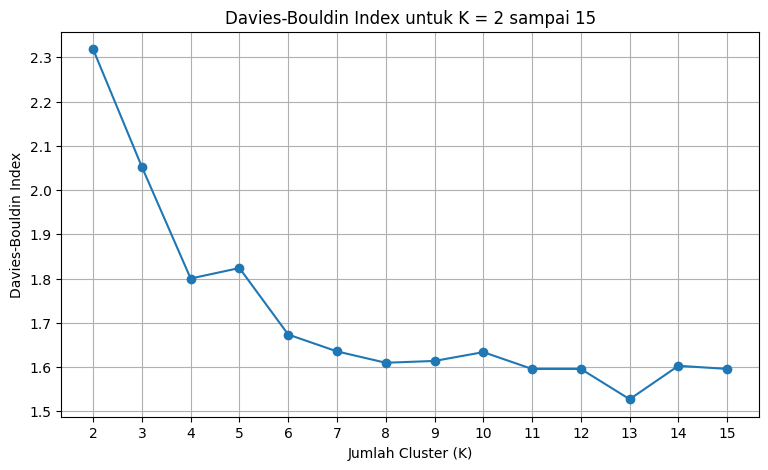

In [41]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(2, 16),
    dbi_scores,
    marker="o"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Index untuk K = 2 sampai 15")
plt.xticks(range(2, 16))
plt.grid(True)
plt.show()

### Perbandingan Kandidat K = 13 dan K = 14

Hasil evaluasi menunjukkan adanya perbedaan antara Silhouette Score dan
Davies-Bouldin Index. Silhouette Score tertinggi diperoleh pada K = 14,
sedangkan Davies-Bouldin Index terendah diperoleh pada K = 13.

Oleh karena itu, K = 13 dan K = 14 dibandingkan lebih lanjut berdasarkan
nilai evaluasi dan distribusi jumlah anggota cluster sebelum menentukan
konfigurasi model final.

In [42]:
# Membandingkan K = 13 dan K = 14

hasil_perbandingan = []

for k in [13, 14]:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    dbi = davies_bouldin_score(X_scaled, labels)

    hasil_perbandingan.append({
        "K": k,
        "Silhouette Score": sil,
        "Davies-Bouldin Index": dbi
    })

perbandingan_df = pd.DataFrame(hasil_perbandingan)

display(perbandingan_df.round(4))

,K,Silhouette Score,Davies-Bouldin Index
0,13,0.1868,1.5273
1,14,0.1894,1.6028


In [43]:
# Jumlah anggota pada K = 13

kmeans_13 = KMeans(
    n_clusters=13,
    random_state=42,
    n_init=10
)

labels_13 = kmeans_13.fit_predict(X_scaled)

cluster_counts_13 = (
    pd.Series(labels_13)
    .value_counts()
    .sort_index()
)

print("Jumlah anggota setiap cluster untuk K = 13:")
display(cluster_counts_13.to_frame("Jumlah Data"))

Jumlah anggota setiap cluster untuk K = 13:


,Jumlah Data
0,184
1,237
2,166
3,134
4,132
5,203
6,131
7,140
8,134
9,136


### Penetapan Jumlah Cluster Final

Berdasarkan hasil evaluasi, K = 13 dipilih sebagai jumlah cluster final. Pada K = 13
diperoleh Silhouette Score sebesar **0,1868** dan Davies-Bouldin Index sebesar
**1,5273**.

Meskipun K = 14 memiliki Silhouette Score yang sedikit lebih tinggi, perbedaannya
relatif kecil. K = 13 memiliki Davies-Bouldin Index yang lebih rendah dan menghasilkan
ukuran cluster yang tetap seimbang, sehingga dipilih sebagai konfigurasi model final.

In [44]:
# Membentuk model K-Means final dengan K = 13

kmeans_final = KMeans(
    n_clusters=13,
    random_state=42,
    n_init=10
)

# Menentukan cluster final
df["Cluster"] = kmeans_final.fit_predict(X_scaled)

print("Model K-Means final berhasil dibuat.")
print("Jumlah data:", len(df))
print("Jumlah cluster:", df["Cluster"].nunique())

Model K-Means final berhasil dibuat.
Jumlah data: 2087
Jumlah cluster: 13


In [45]:
# Mengecek jumlah anggota setiap cluster

cluster_counts_final = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

display(cluster_counts_final.to_frame("Jumlah Data"))

,Jumlah Data
Cluster,
0,184
1,237
2,166
3,134
4,132
5,203
6,131
7,140
8,134


### Analisis Karakteristik Cluster Final

Setelah jumlah cluster final ditetapkan sebanyak 13 cluster, dilakukan analisis
terhadap karakteristik masing-masing cluster berdasarkan nilai rata-rata fitur
yang digunakan dalam proses clustering.

Analisis ini bertujuan untuk mengetahui perbedaan karakteristik fisik dan pola
hidup pada setiap cluster yang terbentuk.

In [46]:
# Profil rata-rata 13 cluster final

cluster_profile_final = (
    df.groupby("Cluster")[cluster_features]
    .mean()
)

display(cluster_profile_final.round(2))

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
Cluster,,,,,,,,
0,22.91,1.75,89.93,2.00,2.69,2.14,0.44,1.35
1,25.92,1.79,106.51,1.97,2.94,2.16,0.96,0.28
2,21.76,1.63,62.76,2.38,3.09,1.80,0.92,0.07
3,20.83,1.73,72.93,2.01,3.01,2.35,2.34,1.40
4,24.34,1.65,103.01,2.94,2.60,1.23,0.44,0.78
5,21.32,1.61,64.76,2.33,1.13,1.93,0.59,0.67
6,20.15,1.78,71.51,2.73,3.31,2.33,2.15,0.31
7,19.90,1.67,61.15,2.88,3.07,1.95,1.31,1.15
8,20.20,1.66,62.54,1.66,3.10,1.40,0.75,1.13


In [47]:
# Profil cluster dan jumlah anggota

cluster_summary_final = cluster_profile_final.copy()

cluster_summary_final["Jumlah Data"] = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

display(cluster_summary_final.round(2))

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Jumlah Data
Cluster,,,,,,,,,
0,22.91,1.75,89.93,2.00,2.69,2.14,0.44,1.35,184
1,25.92,1.79,106.51,1.97,2.94,2.16,0.96,0.28,237
2,21.76,1.63,62.76,2.38,3.09,1.80,0.92,0.07,166
3,20.83,1.73,72.93,2.01,3.01,2.35,2.34,1.40,134
4,24.34,1.65,103.01,2.94,2.60,1.23,0.44,0.78,132
5,21.32,1.61,64.76,2.33,1.13,1.93,0.59,0.67,203
6,20.15,1.78,71.51,2.73,3.31,2.33,2.15,0.31,131
7,19.90,1.67,61.15,2.88,3.07,1.95,1.31,1.15,140
8,20.20,1.66,62.54,1.66,3.10,1.40,0.75,1.13,134


### Visualisasi Profil Relatif Cluster Final

Untuk membandingkan karakteristik antarcluster secara lebih mudah, nilai rata-rata
setiap fitur pada cluster distandardisasi kembali berdasarkan rata-rata antarcluster.

Visualisasi ini digunakan untuk melihat fitur yang relatif lebih tinggi atau lebih
rendah pada masing-masing cluster final.

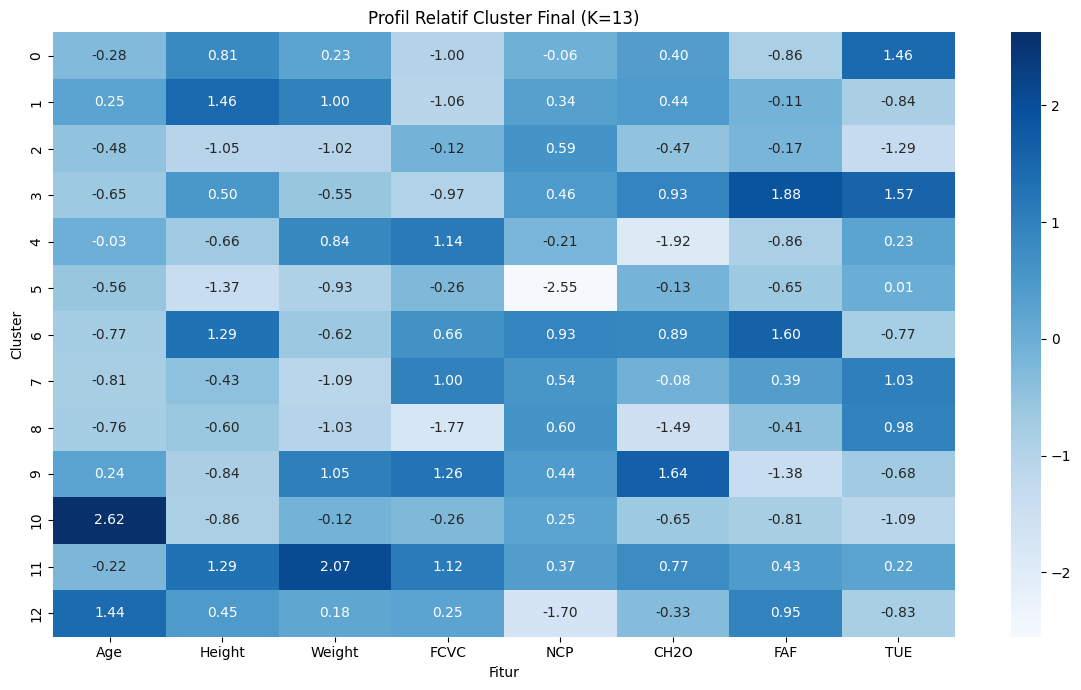

In [48]:
# Standardisasi profil rata-rata cluster final

cluster_profile_scaled_final = (
    cluster_profile_final - cluster_profile_final.mean()
) / cluster_profile_final.std()

plt.figure(figsize=(12, 7))

sns.heatmap(
    cluster_profile_scaled_final,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    center=0
)

plt.title("Profil Relatif Cluster Final (K=13)")
plt.xlabel("Fitur")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

### Visualisasi Cluster Final dengan PCA

Principal Component Analysis (PCA) digunakan untuk mereduksi delapan fitur numerik
menjadi dua komponen utama agar hasil clustering dapat divisualisasikan dalam ruang
dua dimensi.

PCA hanya digunakan untuk visualisasi dan tidak digunakan dalam proses pembentukan
cluster. Model K-Means tetap dibentuk menggunakan delapan fitur numerik yang telah
distandardisasi.

In [49]:
from sklearn.decomposition import PCA

# PCA untuk visualisasi cluster final
pca_final = PCA(n_components=2)

X_pca_final = pca_final.fit_transform(X_scaled)

pca_final_df = pd.DataFrame(
    X_pca_final,
    columns=["PC1", "PC2"]
)

pca_final_df["Cluster"] = df["Cluster"].values

print(
    "Variance PC1:",
    round(pca_final.explained_variance_ratio_[0], 4)
)

print(
    "Variance PC2:",
    round(pca_final.explained_variance_ratio_[1], 4)
)

print(
    "Total variance:",
    round(pca_final.explained_variance_ratio_.sum(), 4)
)

Variance PC1: 0.2255
Variance PC2: 0.1876
Total variance: 0.4131


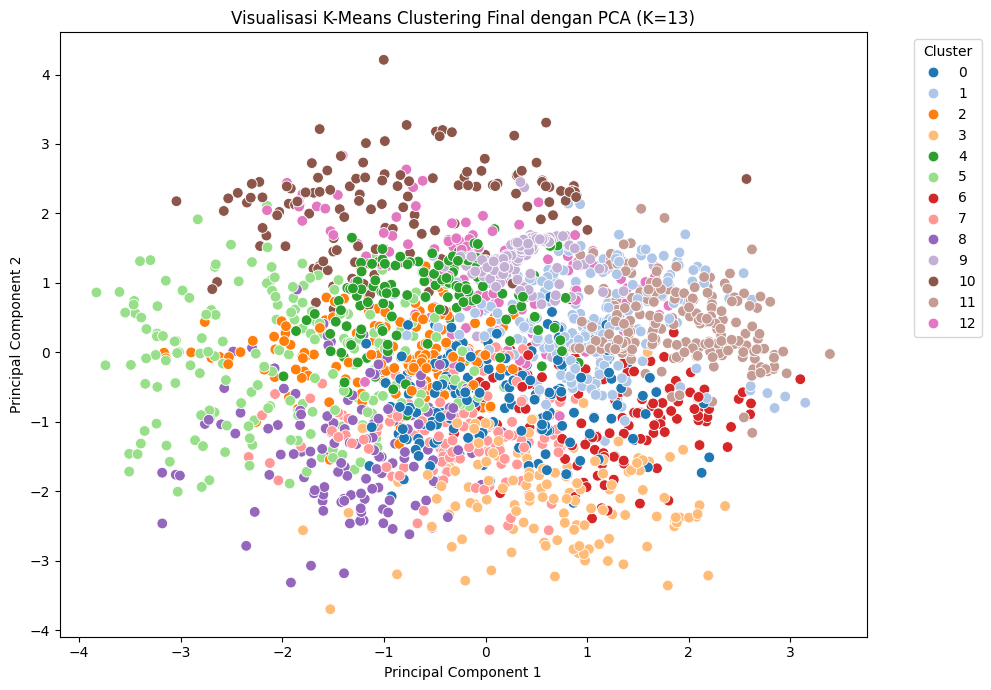

In [50]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_final_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab20",
    s=60
)

plt.title("Visualisasi K-Means Clustering Final dengan PCA (K=13)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Analisis Distribusi NObeyesdad pada Cluster Final

Untuk membantu memahami karakteristik cluster final, dilakukan analisis terhadap
distribusi kategori `NObeyesdad` pada masing-masing cluster.

Variabel `NObeyesdad` tidak digunakan dalam pembentukan cluster. Analisis ini hanya
digunakan sebagai informasi tambahan setelah clustering untuk melihat komposisi
kategori pada setiap kelompok yang terbentuk.

In [51]:
# Persentase NObeyesdad pada setiap cluster final

cluster_obesity_pct_final = pd.crosstab(
    df["Cluster"],
    df["NObeyesdad"],
    normalize="index"
) * 100

display(cluster_obesity_pct_final.round(2))

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,3.26,8.15,30.98,9.24,0.00,17.39,30.98
1,0.00,3.80,25.74,49.37,0.00,5.91,15.19
2,21.08,32.53,10.24,0.60,0.00,30.12,5.42
3,23.13,24.63,19.40,0.00,0.00,14.93,17.91
4,0.00,1.52,8.33,31.82,53.03,1.52,3.79
5,22.17,20.69,23.65,0.49,0.00,19.70,13.30
6,35.88,25.19,6.11,0.00,0.00,20.61,12.21
7,42.14,21.43,3.57,0.00,0.00,12.86,20.00
8,31.34,33.58,13.43,0.00,0.00,11.94,9.70


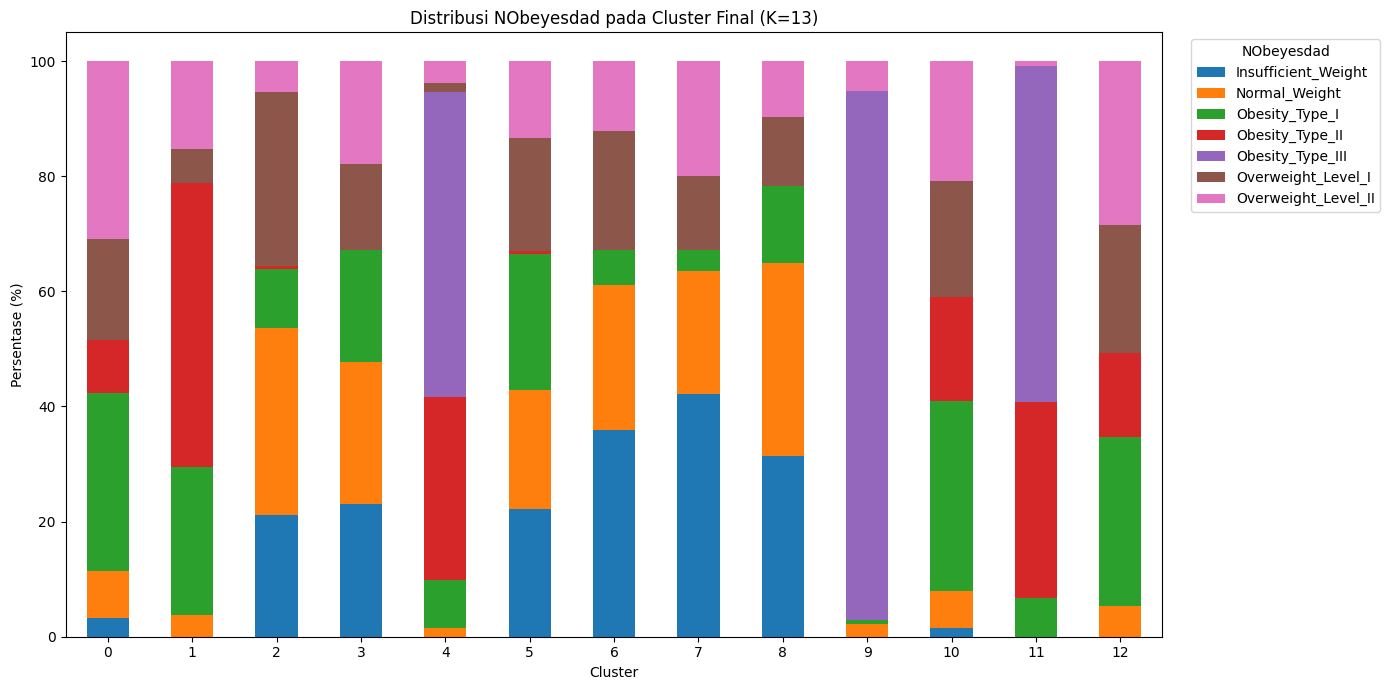

In [52]:
# Visualisasi persentase NObeyesdad pada cluster final

cluster_obesity_pct_final.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Distribusi NObeyesdad pada Cluster Final (K=13)")
plt.xlabel("Cluster")
plt.ylabel("Persentase (%)")
plt.legend(
    title="NObeyesdad",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Ringkasan Karakteristik Cluster

Setiap cluster diinterpretasikan berdasarkan karakteristik fisik, pola hidup, jumlah
anggota, serta kategori `NObeyesdad` yang paling dominan. Kategori `NObeyesdad`
digunakan sebagai informasi tambahan dan tidak digunakan dalam pembentukan cluster.

In [53]:
# Menentukan kategori NObeyesdad yang paling dominan pada setiap cluster

dominant_category = cluster_obesity_pct_final.idxmax(axis=1)
dominant_percentage = cluster_obesity_pct_final.max(axis=1)

cluster_interpretation = cluster_summary_final.copy()

cluster_interpretation["Kategori Dominan"] = dominant_category
cluster_interpretation["Persentase Dominan (%)"] = dominant_percentage

display(cluster_interpretation.round(2))

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Jumlah Data,Kategori Dominan,Persentase Dominan (%)
Cluster,,,,,,,,,,,
0,22.91,1.75,89.93,2.00,2.69,2.14,0.44,1.35,184,Obesity_Type_I,30.98
1,25.92,1.79,106.51,1.97,2.94,2.16,0.96,0.28,237,Obesity_Type_II,49.37
2,21.76,1.63,62.76,2.38,3.09,1.80,0.92,0.07,166,Normal_Weight,32.53
3,20.83,1.73,72.93,2.01,3.01,2.35,2.34,1.40,134,Normal_Weight,24.63
4,24.34,1.65,103.01,2.94,2.60,1.23,0.44,0.78,132,Obesity_Type_III,53.03
5,21.32,1.61,64.76,2.33,1.13,1.93,0.59,0.67,203,Obesity_Type_I,23.65
6,20.15,1.78,71.51,2.73,3.31,2.33,2.15,0.31,131,Insufficient_Weight,35.88
7,19.90,1.67,61.15,2.88,3.07,1.95,1.31,1.15,140,Insufficient_Weight,42.14
8,20.20,1.66,62.54,1.66,3.10,1.40,0.75,1.13,134,Normal_Weight,33.58


## 5. Evaluation

### Hasil Evaluasi Model

Model K-Means final menggunakan 13 cluster berdasarkan hasil perbandingan beberapa
nilai jumlah cluster.

Pada K = 13 diperoleh:

- Silhouette Score = **0,1868**
- Davies-Bouldin Index = **1,5273**

Silhouette Score menunjukkan tingkat kesesuaian data terhadap cluster yang terbentuk,
sedangkan Davies-Bouldin Index digunakan untuk melihat tingkat kemiripan antarcluster.
Hasil evaluasi menunjukkan bahwa pemisahan cluster masih memiliki tingkat overlap,
sehingga struktur cluster belum tergolong sangat kuat.

Meskipun demikian, model menghasilkan 13 cluster dengan jumlah anggota yang relatif
tersebar, yaitu antara **130 hingga 237 data per cluster**. Hasil analisis profil
cluster juga menunjukkan adanya perbedaan karakteristik pada aspek usia, tinggi badan,
berat badan, pola makan, konsumsi air, aktivitas fisik, dan penggunaan teknologi.

Analisis tambahan terhadap `NObeyesdad` menunjukkan bahwa komposisi kategori pada
setiap cluster berbeda. Variabel tersebut tidak digunakan dalam pembentukan cluster
dan hanya digunakan untuk membantu interpretasi hasil clustering.

In [55]:
# Ringkasan evaluasi model final

evaluation_summary = pd.DataFrame({
    "Metrik": [
        "Jumlah Data",
        "Jumlah Fitur",
        "Jumlah Cluster",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Cluster Terkecil",
        "Cluster Terbesar"
    ],
    "Nilai": [
        len(df),
        len(cluster_features),
        13,
        silhouette_score(X_scaled, df["Cluster"]),
        davies_bouldin_score(X_scaled, df["Cluster"]),
        cluster_counts_final.min(),
        cluster_counts_final.max()
    ]
})

display(evaluation_summary)

,Metrik,Nilai
0,Jumlah Data,2087.000000
1,Jumlah Fitur,8.000000
2,Jumlah Cluster,13.000000
3,Silhouette Score,0.186773
4,Davies-Bouldin Index,1.527250
5,Cluster Terkecil,130.000000
6,Cluster Terbesar,237.000000


## 6. Deployment

### Penyimpanan Model

Model K-Means dan `StandardScaler` yang telah digunakan pada proses clustering
disimpan agar dapat digunakan kembali pada aplikasi deployment.

Model yang disimpan terdiri dari:
- `kmeans_final` sebagai model clustering dengan 13 cluster.
- `scaler` sebagai objek standardisasi yang digunakan pada data sebelum clustering.

In [56]:
import joblib

# Menyimpan model K-Means
joblib.dump(kmeans_final, "kmeans_model.pkl")

# Menyimpan scaler
joblib.dump(scaler, "scaler.pkl")

print("Model K-Means berhasil disimpan sebagai kmeans_model.pkl")
print("Scaler berhasil disimpan sebagai scaler.pkl")

Model K-Means berhasil disimpan sebagai kmeans_model.pkl
Scaler berhasil disimpan sebagai scaler.pkl


### Pengujian Model yang Disimpan

Model K-Means dan StandardScaler yang telah disimpan dimuat kembali untuk
memastikan keduanya dapat digunakan untuk melakukan segmentasi terhadap data baru.

In [58]:
# Memuat kembali model dan scaler

import joblib
import pandas as pd

loaded_kmeans = joblib.load("kmeans_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

print("Model dan scaler berhasil dimuat kembali.")

Model dan scaler berhasil dimuat kembali.


In [60]:
# Contoh data baru

data_baru = pd.DataFrame({
    "Age": [22],
    "Height": [1.75],
    "Weight": [70],
    "FCVC": [2],
    "NCP": [3],
    "CH2O": [2],
    "FAF": [2],
    "TUE": [1]
})

# Memastikan urutan fitur sama dengan saat training
data_baru = data_baru[cluster_features]

# Standardisasi data baru
data_baru_scaled = loaded_scaler.transform(data_baru)

# Mengubah hasil standardisasi menjadi DataFrame
data_baru_scaled = pd.DataFrame(
    data_baru_scaled,
    columns=cluster_features
)

# Prediksi cluster
cluster_hasil = loaded_kmeans.predict(data_baru_scaled)

print("Data baru termasuk ke Cluster:", cluster_hasil[0])

Data baru termasuk ke Cluster: 3


### Penyimpanan Profil Cluster

Selain model K-Means dan StandardScaler, profil rata-rata setiap cluster disimpan
agar dapat digunakan pada aplikasi deployment untuk menampilkan karakteristik
cluster yang dihasilkan.

In [61]:
# Menambahkan kategori dominan ke profil cluster final

cluster_profile_app = cluster_profile_final.copy()

cluster_profile_app["Jumlah Data"] = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_profile_app["Kategori Dominan"] = (
    cluster_obesity_pct_final.idxmax(axis=1)
)

cluster_profile_app["Persentase Dominan (%)"] = (
    cluster_obesity_pct_final.max(axis=1)
)

display(cluster_profile_app.round(2))

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Jumlah Data,Kategori Dominan,Persentase Dominan (%)
Cluster,,,,,,,,,,,
0,22.91,1.75,89.93,2.00,2.69,2.14,0.44,1.35,184,Obesity_Type_I,30.98
1,25.92,1.79,106.51,1.97,2.94,2.16,0.96,0.28,237,Obesity_Type_II,49.37
2,21.76,1.63,62.76,2.38,3.09,1.80,0.92,0.07,166,Normal_Weight,32.53
3,20.83,1.73,72.93,2.01,3.01,2.35,2.34,1.40,134,Normal_Weight,24.63
4,24.34,1.65,103.01,2.94,2.60,1.23,0.44,0.78,132,Obesity_Type_III,53.03
5,21.32,1.61,64.76,2.33,1.13,1.93,0.59,0.67,203,Obesity_Type_I,23.65
6,20.15,1.78,71.51,2.73,3.31,2.33,2.15,0.31,131,Insufficient_Weight,35.88
7,19.90,1.67,61.15,2.88,3.07,1.95,1.31,1.15,140,Insufficient_Weight,42.14
8,20.20,1.66,62.54,1.66,3.10,1.40,0.75,1.13,134,Normal_Weight,33.58


In [64]:
# Menyimpan profil cluster untuk kebutuhan deployment

cluster_profile_app.to_csv(
    "cluster_profile.csv",
    index_label="Cluster"
)

print("Profil cluster berhasil disimpan sebagai cluster_profile.csv")

Profil cluster berhasil disimpan sebagai cluster_profile.csv
